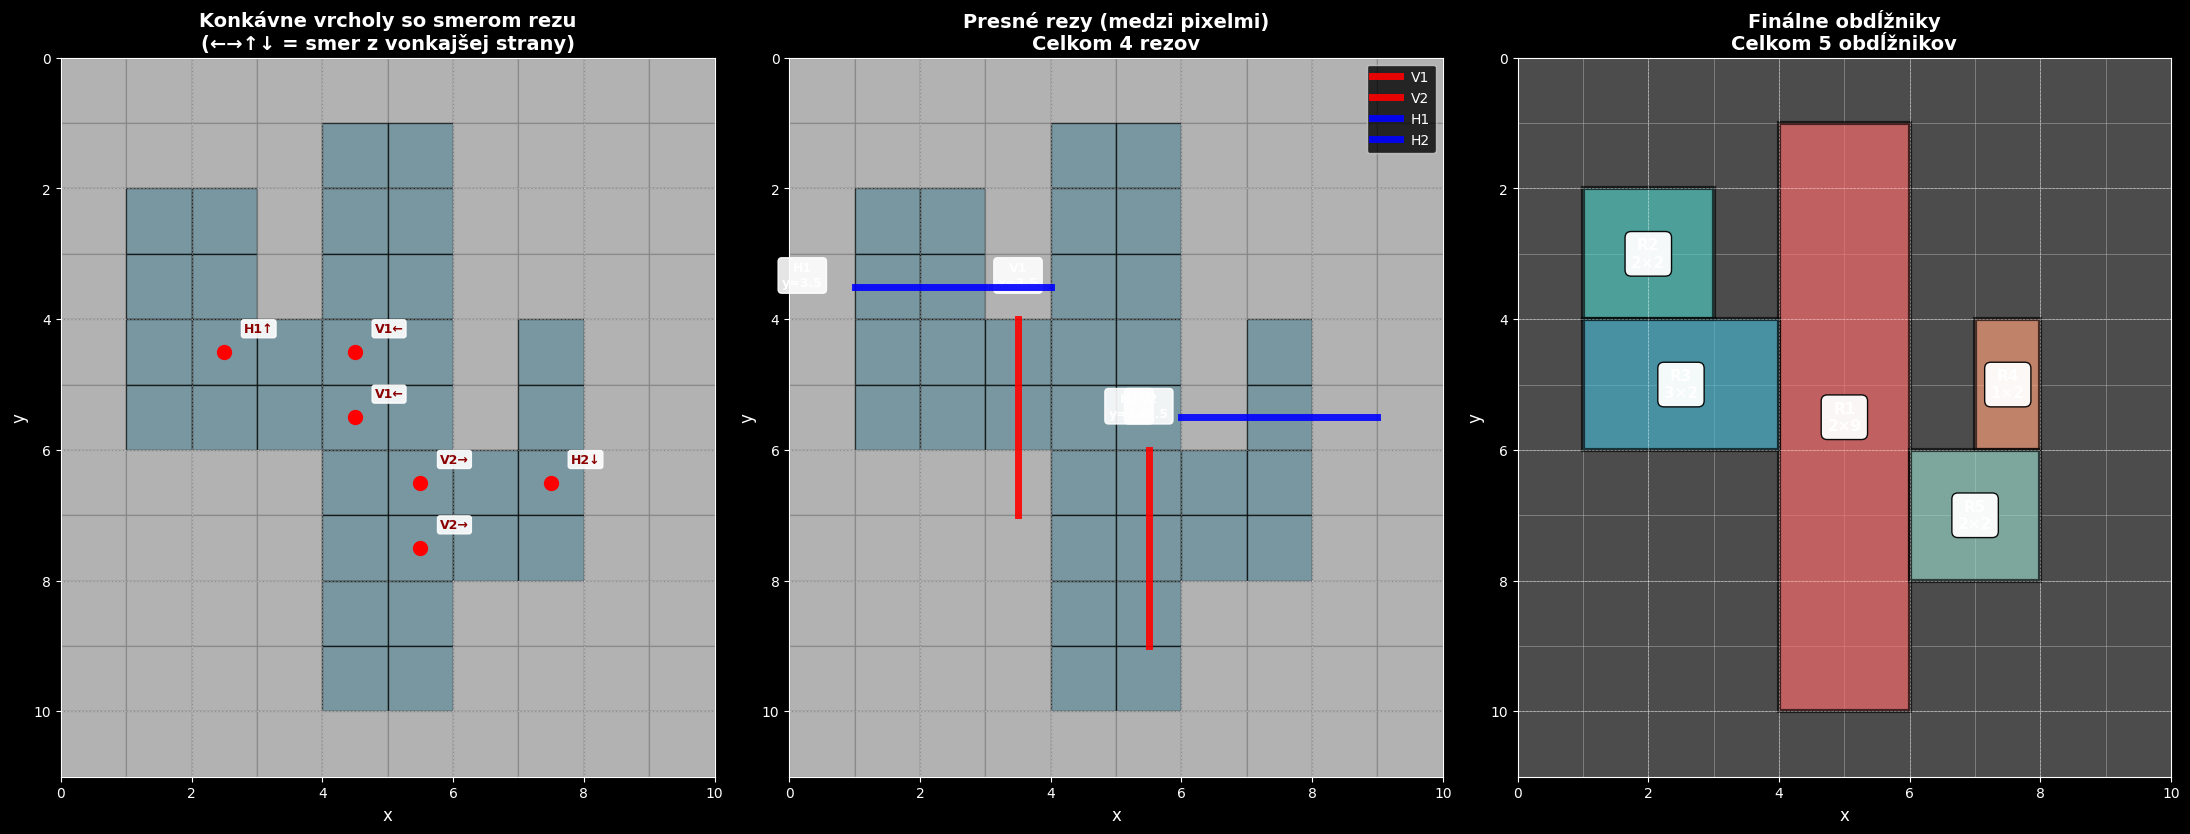

FER ALGORITMUS - PRESNÉ REZY

✂️ Presné rezy (z vonkajšej strany konkávnych vrcholov):

Level 1 (kogrid páry):
  V1: x=3.5 (medzi pixelmi), y=4→6, strana=left
  V2: x=5.5 (medzi pixelmi), y=6→8, strana=right

Level 2 (sekvenčné):
  H1: y=3.5 (medzi pixelmi), x=1→3, strana=top
  H2: y=5.5 (medzi pixelmi), x=6→8, strana=bottom

📦 Obdĺžniky: 5
  R1: (4,1)→(5,9), 2×9, 18px
  R2: (1,2)→(2,3), 2×2, 4px
  R3: (1,4)→(3,5), 3×2, 6px
  R4: (7,4)→(7,5), 1×2, 2px
  R5: (6,6)→(7,7), 2×2, 4px

✅ Pokrytie: 34/34 ✓


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from collections import deque

img = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
])

# Optimálne rezy s PRESNOU pozíciou (medzi pixelmi)
# Rezy sú definované ako hranice medzi pixelmi

# Level 1: vertikálne kogrid páry
level1_cuts = [
    {
        'type': 'vertical',
        'x_line': 3.5,  # Medzi x=3 a x=4 (z ľavej strany vrcholu 4,4 a 4,5)
        'y_range': (4, 6),  # Od y=4 do y=6 (vrátane)
        'label': 'V1',
        'side': 'left'
    },
    {
        'type': 'vertical',
        'x_line': 5.5,  # Medzi x=5 a x=6 (z pravej strany vrcholu 5,6 a 5,7)
        'y_range': (6, 8),  # Od y=6 do y=8 (vrátane)
        'label': 'V2',
        'side': 'right'
    },
]

# Level 2: sekvenčné rezy zo zvyšných konkávnych vrcholov
level2_cuts = [
    {
        'type': 'horizontal',
        'y_line': 3.5,  # Medzi y=3 a y=4 (z hornej strany vrcholu 2,4)
        'x_range': (1, 3),  # Od x=1 do x=3
        'label': 'H1',
        'side': 'top'
    },
    {
        'type': 'horizontal',
        'y_line': 5.5,  # Medzi y=5 a y=6 (z dolnej strany vrcholu 7,6)
        'x_range': (6, 8),  # Od x=6 do x=8
        'label': 'H2',
        'side': 'bottom'
    },
]

all_cuts = level1_cuts + level2_cuts

def find_rectangles_with_precise_cuts(img, cuts):
    """
    Nájde obdĺžniky s presnými rezmi medzi pixelmi.
    Rezy sú definované ako presné hranice (x.5 alebo y.5).
    """
    rows, cols = img.shape

    # Mapa regiónov
    region_map = np.full((rows, cols), -1, dtype=int)
    region_id = 0

    def is_cut_between(y1, x1, y2, x2):
        """Kontrola, či je medzi dvoma susednými pixelmi rez."""
        for cut in cuts:
            if cut['type'] == 'vertical':
                # Vertikálny rez je medzi stĺpcami
                x_line = cut['x_line']
                y_start, y_end = cut['y_range']

                # Kontrola horizontálneho pohybu cez vertikálny rez
                if y1 == y2 and abs(x1 - x2) == 1:
                    x_border = (min(x1, x2) + max(x1, x2)) / 2.0
                    if abs(x_border - x_line) < 0.1 and y_start <= y1 <= y_end:
                        return True

            else:  # horizontal
                # Horizontálny rez je medzi riadkami
                y_line = cut['y_line']
                x_start, x_end = cut['x_range']

                # Kontrola vertikálneho pohybu cez horizontálny rez
                if x1 == x2 and abs(y1 - y2) == 1:
                    y_border = (min(y1, y2) + max(y1, y2)) / 2.0
                    if abs(y_border - y_line) < 0.1 and x_start <= x1 <= x_end:
                        return True

        return False

    def flood_fill(start_y, start_x, region_id):
        """BFS flood fill - prechádza len cez pixely bez rezov."""
        queue = deque([(start_y, start_x)])
        region_map[start_y, start_x] = region_id
        points = [(start_x, start_y)]

        while queue:
            y, x = queue.popleft()

            # 4-súvislost
            for dy, dx in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
                ny, nx = y + dy, x + dx

                if (0 <= ny < rows and 0 <= nx < cols and
                    img[ny, nx] == 1 and
                    region_map[ny, nx] == -1 and
                    not is_cut_between(y, x, ny, nx)):

                    region_map[ny, nx] = region_id
                    queue.append((ny, nx))
                    points.append((nx, ny))

        return points

    rectangles = []

    # Nájdeme všetky regióny
    for i in range(rows):
        for j in range(cols):
            if img[i, j] == 1 and region_map[i, j] == -1:
                points = flood_fill(i, j, region_id)

                if len(points) > 0:
                    xs = [p[0] for p in points]
                    ys = [p[1] for p in points]
                    min_x, max_x = min(xs), max(xs)
                    min_y, max_y = min(ys), max(ys)

                    rectangles.append({
                        'min_x': min_x,
                        'min_y': min_y,
                        'max_x': max_x,
                        'max_y': max_y,
                        'width': max_x - min_x + 1,
                        'height': max_y - min_y + 1,
                        'points': points,
                        'area': len(points)
                    })

                region_id += 1

    return rectangles

# Nájdeme obdĺžniky
rectangles = find_rectangles_with_precise_cuts(img, all_cuts)

# Overenie pokrytia
covered_pixels = set()
for rect in rectangles:
    for point in rect['points']:
        covered_pixels.add(point)

original_pixels = set()
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        if img[i, j] == 1:
            original_pixels.add((j, i))

# Vizualizácia
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

rows, cols = img.shape

# ===== AX1: Pôvodný obraz =====
ax1 = axes[0]
for i in range(rows):
    for j in range(cols):
        color = 'lightblue' if img[i, j] == 1 else 'white'
        rect = Rectangle((j, i), 1, 1, linewidth=1,
                        edgecolor='black' if img[i, j] == 1 else 'gray',
                        facecolor=color, alpha=0.7)
        ax1.add_patch(rect)

# Konkávne vrcholy s označením smeru rezu
concave_info = [
    ((2, 4), 'H1↑'),
    ((4, 4), 'V1←'),
    ((4, 5), 'V1←'),
    ((5, 6), 'V2→'),
    ((7, 6), 'H2↓'),
    ((5, 7), 'V2→'),
]

for (x, y), label in concave_info:
    ax1.plot(x + 0.5, y + 0.5, 'ro', markersize=10, zorder=5)
    ax1.text(x + 0.8, y + 0.2, label, fontsize=9, fontweight='bold',
             color='darkred', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9))

ax1.set_xlim(0, cols)
ax1.set_ylim(0, rows)
ax1.set_aspect('equal')
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax1.invert_yaxis()
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_title('Konkávne vrcholy so smerom rezu\n(←→↑↓ = smer z vonkajšej strany)',
             fontsize=14, fontweight='bold')

# ===== AX2: S rezmi =====
ax2 = axes[1]
for i in range(rows):
    for j in range(cols):
        color = 'lightblue' if img[i, j] == 1 else 'white'
        rect = Rectangle((j, i), 1, 1, linewidth=1,
                        edgecolor='black' if img[i, j] == 1 else 'gray',
                        facecolor=color, alpha=0.7)
        ax2.add_patch(rect)

# Vykreslenie rezov ako hrubých čiar PRESNE medzi pixelmi
for cut in all_cuts:
    if cut['type'] == 'vertical':
        x_line = cut['x_line']
        y_start, y_end = cut['y_range']
        color = 'red'
        ax2.plot([x_line, x_line], [y_start, y_end + 1],
                '-', color=color, linewidth=5, label=cut['label'], zorder=5, alpha=0.9)
        # Označenie pozície
        ax2.text(x_line, y_start - 0.5, f"{cut['label']}\nx={x_line}",
                ha='center', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))
    else:  # horizontal
        y_line = cut['y_line']
        x_start, x_end = cut['x_range']
        color = 'blue'
        ax2.plot([x_start, x_end + 1], [y_line, y_line],
                '-', color=color, linewidth=5, label=cut['label'], zorder=5, alpha=0.9)
        # Označenie pozície
        ax2.text(x_start - 0.8, y_line, f"{cut['label']}\ny={y_line}",
                ha='center', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))

ax2.set_xlim(0, cols)
ax2.set_ylim(0, rows)
ax2.set_aspect('equal')
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax2.invert_yaxis()
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_title(f'Presné rezy (medzi pixelmi)\nCelkom {len(all_cuts)} rezov',
             fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)

# ===== AX3: Finálne obdĺžniky =====
ax3 = axes[2]

# Pozadie
for i in range(rows):
    for j in range(cols):
        rect = Rectangle((j, i), 1, 1, linewidth=0.5, edgecolor='lightgray',
                        facecolor='white', alpha=0.3)
        ax3.add_patch(rect)

# Obdĺžniky
colors_palette = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8',
                  '#F7DC6F', '#BB8FCE', '#85C1E2']

for idx, rect_data in enumerate(rectangles):
    color = colors_palette[idx % len(colors_palette)]

    rect = Rectangle(
        (rect_data['min_x'], rect_data['min_y']),
        rect_data['width'],
        rect_data['height'],
        linewidth=3,
        edgecolor='black',
        facecolor=color,
        alpha=0.65
    )
    ax3.add_patch(rect)

    center_x = rect_data['min_x'] + rect_data['width'] / 2
    center_y = rect_data['min_y'] + rect_data['height'] / 2

    ax3.text(center_x, center_y, f"R{idx+1}\n{rect_data['width']}×{rect_data['height']}",
            ha='center', va='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.95, edgecolor='black'))

ax3.set_xlim(0, cols)
ax3.set_ylim(0, rows)
ax3.set_aspect('equal')
ax3.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax3.invert_yaxis()
ax3.set_xlabel('x', fontsize=12)
ax3.set_ylabel('y', fontsize=12)
ax3.set_title(f'Finálne obdĺžniky\nCelkom {len(rectangles)} obdĺžnikov',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/tmp/fer_correct_cuts.png', dpi=150, bbox_inches='tight')
plt.show()

# Výpis
print("=" * 70)
print("FER ALGORITMUS - PRESNÉ REZY")
print("=" * 70)

print(f"\n✂️ Presné rezy (z vonkajšej strany konkávnych vrcholov):")
print(f"\nLevel 1 (kogrid páry):")
for cut in level1_cuts:
    print(f"  {cut['label']}: x={cut['x_line']} (medzi pixelmi), y={cut['y_range'][0]}→{cut['y_range'][1]}, strana={cut['side']}")

print(f"\nLevel 2 (sekvenčné):")
for cut in level2_cuts:
    print(f"  {cut['label']}: y={cut['y_line']} (medzi pixelmi), x={cut['x_range'][0]}→{cut['x_range'][1]}, strana={cut['side']}")

print(f"\n📦 Obdĺžniky: {len(rectangles)}")
for idx, rect in enumerate(rectangles, 1):
    print(f"  R{idx}: ({rect['min_x']},{rect['min_y']})→({rect['max_x']},{rect['max_y']}), {rect['width']}×{rect['height']}, {rect['area']}px")

print(f"\n✅ Pokrytie: {len(covered_pixels)}/{len(original_pixels)} {'✓' if covered_pixels == original_pixels else '✗'}")

In [21]:
import numpy as np
from collections import defaultdict


def find_concave_corners(grid):
    rows, cols = grid.shape
    concave_points = []

    for y in range(1, rows - 1):
        for x in range(1, cols - 1):
            if grid[y, x] == 1:
                # Direct neighbors (Up, Down, Left, Right)
                t, b = grid[y-1, x], grid[y+1, x]
                l, r = grid[y, x-1], grid[y, x+1]

                # Diagonal neighbors
                tl, tr = grid[y-1, x-1], grid[y-1, x+1]
                bl, br = grid[y+1, x-1], grid[y+1, x+1]

                # A pixel is concave if it has two orthogonal neighbors (1)
                # but their shared diagonal is background (0)
                is_concave = (
                    (t == 1 and l == 1 and tl == 0) or
                    (t == 1 and r == 1 and tr == 0) or
                    (b == 1 and l == 1 and bl == 0) or
                    (b == 1 and r == 1 and br == 0)
                )

                if is_concave:
                    concave_points.append((x, y))

    return concave_points

def find_cogrid_pairs(concave_vertices):
    """
    Nájde kogrid páry - vrcholy so spoločnou x alebo y súradnicou.
    Vracia možné chody (tetivy).
    """
    chords = []

    # Horizontálne páry (rovnaká y-súradnica)
    y_groups = defaultdict(list)
    for vertex in concave_vertices:
        x, y = vertex
        y_groups[y].append(vertex)

    chord_id = 0
    for y, vertices in y_groups.items():
        if len(vertices) >= 2:
            # Vytvoríme chody medzi všetkými pármi v tejto y-súradnici
            for i in range(len(vertices)):
                for j in range(i + 1, len(vertices)):
                    v1, v2 = vertices[i], vertices[j]
                    chords.append({
                        'id': chord_id,
                        'type': 'horizontal',
                        'v1': v1,
                        'v2': v2,
                        'y': y,
                        'x_range': (min(v1[0], v2[0]), max(v1[0], v2[0]))
                    })
                    chord_id += 1

    # Vertikálne páry (rovnaká x-súradnica)
    x_groups = defaultdict(list)
    for vertex in concave_vertices:
        x, y = vertex
        x_groups[x].append(vertex)

    for x, vertices in x_groups.items():
        if len(vertices) >= 2:
            # Vytvoríme chody medzi všetkými pármi v tejto x-súradnici
            for i in range(len(vertices)):
                for j in range(i + 1, len(vertices)):
                    v1, v2 = vertices[i], vertices[j]
                    chords.append({
                        'id': chord_id,
                        'type': 'vertical',
                        'v1': v1,
                        'v2': v2,
                        'x': x,
                        'y_range': (min(v1[1], v2[1]), max(v1[1], v2[1]))
                    })
                    chord_id += 1

    return chords

def chords_intersect(chord1, chord2):
    """
    Kontrola, či sa dve chody pretínajú alebo majú spoločný vrchol.
    """
    # Spoločný vrchol
    if (chord1['v1'] == chord2['v1'] or chord1['v1'] == chord2['v2'] or
        chord1['v2'] == chord2['v1'] or chord1['v2'] == chord2['v2']):
        return True

    # Horizontálne chody sa nikdy nepretínajú medzi sebou
    if chord1['type'] == 'horizontal' and chord2['type'] == 'horizontal':
        return False

    # Vertikálne chody sa nikdy nepretínajú medzi sebou
    if chord1['type'] == 'vertical' and chord2['type'] == 'vertical':
        return False

    # Priesečník horizontálnej a vertikálnej chody
    if chord1['type'] == 'horizontal' and chord2['type'] == 'vertical':
        h_chord, v_chord = chord1, chord2
    else:
        h_chord, v_chord = chord2, chord1

    # Kontrola, či sa pretínajú
    h_y = h_chord['y']
    h_x_min, h_x_max = h_chord['x_range']

    v_x = v_chord['x']
    v_y_min, v_y_max = v_chord['y_range']

    # Pretínajú sa, ak vertikálna chorda prechádza cez horizontálnu
    if h_x_min < v_x < h_x_max and v_y_min < h_y < v_y_max:
        return True

    return False

def build_conflict_graph(chords):
    """
    Vytvorí graf konfliktov - hrana medzi chordami, ktoré sa pretínajú.
    Vracia adjacency list.
    """
    graph = defaultdict(list)

    for i, chord1 in enumerate(chords):
        for j, chord2 in enumerate(chords):
            if i != j and chords_intersect(chord1, chord2):
                graph[chord1['id']].append(chord2['id'])

    return graph

def is_bipartite_graph(chords, graph):
    """
    Overí, či je graf bipartitný (všetky horizontálne vs všetky vertikálne).
    """
    # V našom prípade je graf VŽDY bipartitný, pretože:
    # - horizontálne chody sa nepretínajú medzi sebou
    # - vertikálne chody sa nepretínajú medzi sebou
    # - len horizontal-vertical môžu mať hrany
    return True

def maximum_matching_bipartite(chords, graph):
    """
    Nájde maximálne párovanie v bipartitnom grafe.
    Používa augmenting path algoritmus (DFS-based).
    """
    # Rozdelíme chody na dve množiny
    horizontal = [c for c in chords if c['type'] == 'horizontal']
    vertical = [c for c in chords if c['type'] == 'vertical']

    # Matching: chord_id -> matched_chord_id
    matching = {}

    def dfs_augmenting_path(chord_id, visited):
        """DFS na nájdenie augmentujúcej cesty."""
        for neighbor_id in graph[chord_id]:
            if neighbor_id in visited:
                continue

            visited.add(neighbor_id)

            # Ak sused nie je matchnutý, alebo môžeme nájsť alternatívnu cestu
            if neighbor_id not in matching or dfs_augmenting_path(matching[neighbor_id], visited):
                matching[chord_id] = neighbor_id
                matching[neighbor_id] = chord_id
                return True

        return False

    # Pre každú horizontálnu chodu hľadáme augmentujúcu cestu
    for h_chord in horizontal:
        visited = set()
        dfs_augmenting_path(h_chord['id'], visited)

    # Pre každú vertikalnu chodu hľadáme augmentujúcu cestu
    for v_chord in vertical:
            visited = set()
            dfs_augmenting_path(v_chord['id'], visited)

    # Matching obsahuje páry (každý pár je tam 2x)
    matched_pairs = set()
    for chord_id, matched_id in matching.items():
        pair = tuple(sorted([chord_id, matched_id]))
        matched_pairs.add(pair)

    return matched_pairs

def maximum_independent_set(chords, graph, matching_pairs, preference='auto'):
    """
    Nájde maximálnu nezávislú množinu z maximálneho párovania.

    Args:
        chords: Zoznam všetkých chôrd
        graph: Graf konfliktov
        matching_pairs: Páry z maximálneho párovania
        preference: 'horizontal', 'vertical', alebo 'auto' (vyberie automaticky)

    MIS obsahuje:
    1. Jeden vrchol z každého matchovaného páru (podľa preferencie)
    2. Všetky izolované vrcholy (bez hran)
    3. Niektoré ďalšie vrcholy, ktoré nie sú v matchingu ale sú nezávislé
    """
    # Množina všetkých chord IDs
    all_chord_ids = {c['id'] for c in chords}

    # Chord IDs, ktoré sú v matchingu
    matched_chord_ids = set()
    for pair in matching_pairs:
        matched_chord_ids.add(pair[0])
        matched_chord_ids.add(pair[1])

    # Izolované vrcholy (bez hran)
    isolated = set()
    for chord in chords:
        if len(graph[chord['id']]) == 0:
            isolated.add(chord['id'])

    # Vrcholy, ktoré nie sú v matchingu
    unmatched = all_chord_ids - matched_chord_ids

    # MIS: vyberieme jeden z každého páru + izolované + niektoré unmatched
    mis = set()

    # 1. Izolované vrcholy (vždy ich pridáme)
    mis.update(isolated)

    # 2. Jeden z každého matchovaného páru (podľa preferencie)
    chord_dict = {c['id']: c for c in chords}

    for pair in matching_pairs:
        chord1 = chord_dict[pair[0]]
        chord2 = chord_dict[pair[1]]

        if preference == 'horizontal':
            # Vyberieme horizontálnu chodu, ak existuje
            if chord1['type'] == 'horizontal':
                mis.add(pair[0])
            elif chord2['type'] == 'horizontal':
                mis.add(pair[1])
            else:
                mis.add(pair[0])  # Fallback

        elif preference == 'vertical':
            # Vyberieme vertikálnu chodu, ak existuje
            if chord1['type'] == 'vertical':
                mis.add(pair[0])
            elif chord2['type'] == 'vertical':
                mis.add(pair[1])
            else:
                mis.add(pair[0])  # Fallback

        else:  # 'auto'
            # Vyberieme prvý z páru (pôvodné správanie)
            mis.add(pair[0])

    # 3. Unmatched vrcholy, ktoré sú nezávislé od už vybraných
    for chord_id in unmatched:
        # Skontrolujeme, či je nezávislý od všetkých už vybraných
        is_independent = True
        for selected_id in mis:
            if selected_id in graph[chord_id]:
                is_independent = False
                break

        if is_independent:
            mis.add(chord_id)

    return mis

def fer_algorithm_mis(concave_vertices, preference='auto', verbose=False):
    """
    Hlavný FER algoritmus - Level 1 pomocou MIS.

    Args:
        concave_vertices: Zoznam konkávnych vrcholov
        preference: 'horizontal', 'vertical', alebo 'auto'
        verbose: Ak True, zobrazuje debug výpisy
    """
    if verbose:
        print("=" * 70)
        print("FER ALGORITMUS - MAXIMUM INDEPENDENT SET")
        print(f"Preferencia: {preference.upper()}")
        print("=" * 70)

    # Krok 1: Nájdeme kogrid páry (možné chody)
    chords = find_cogrid_pairs(concave_vertices)

    if verbose:
        print(f"\n📍 Konkávne vrcholy: {len(concave_vertices)}")
        for v in concave_vertices:
            print(f"  • {v}")

        print(f"\n🎯 Možné chody (kogrid páry): {len(chords)}")
        for chord in chords:
            if chord['type'] == 'horizontal':
                print(f"  Chord {chord['id']}: {chord['v1']} ↔ {chord['v2']} (horizontal, y={chord['y']})")
            else:
                print(f"  Chord {chord['id']}: {chord['v1']} ↔ {chord['v2']} (vertical, x={chord['x']})")

    # Krok 2: Vytvoríme konfliktový graf
    graph = build_conflict_graph(chords)

    if verbose:
        print(f"\n🔗 Konfliktový graf (hrany = priesečníky):")
        for chord_id, neighbors in graph.items():
            if neighbors:
                print(f"  Chord {chord_id} konfliktuje s: {neighbors}")

    # Krok 3: Overíme bipartitnosť
    is_bip = is_bipartite_graph(chords, graph)

    if verbose:
        print(f"\n✓ Graf je bipartitný: {is_bip}")

    # Krok 4: Nájdeme maximálne párovanie
    matching_pairs = maximum_matching_bipartite(chords, graph)

    if verbose:
        print(f"\n🔄 Maximálne párovanie: {len(matching_pairs)} párov")
        for pair in matching_pairs:
            chord1 = next(c for c in chords if c['id'] == pair[0])
            chord2 = next(c for c in chords if c['id'] == pair[1])
            print(f"  Pár: Chord {pair[0]} ({chord1['type']}) ↔ Chord {pair[1]} ({chord2['type']})")

    # Krok 5: Nájdeme maximálnu nezávislú množinu
    mis = maximum_independent_set(chords, graph, matching_pairs, preference)

    selected_chords = [c for c in chords if c['id'] in mis]

    if verbose:
        print(f"\n⭐ Maximálna nezávislá množina (MIS): {len(mis)} chôrd")
        for chord in selected_chords:
            if chord['type'] == 'horizontal':
                print(f"  ✓ Chord {chord['id']}: {chord['v1']} ↔ {chord['v2']} (horizontal, y={chord['y']})")
            else:
                print(f"  ✓ Chord {chord['id']}: {chord['v1']} ↔ {chord['v2']} (vertical, x={chord['x']})")

    # Krok 6: Identifikujeme zvyšné konkávne vrcholy
    used_vertices = set()
    for chord in selected_chords:
        used_vertices.add(chord['v1'])
        used_vertices.add(chord['v2'])

    remaining_vertices = [v for v in concave_vertices if v not in used_vertices]

    if verbose:
        print(f"\n📌 Zvyšné konkávne vrcholy (pre Level 2): {len(remaining_vertices)}")
        for v in remaining_vertices:
            print(f"  • {v}")

        print(f"\n✅ Level 1 dokončený: {len(selected_chords)} rezov z MIS")
        print(f"✅ Level 2 potrebuje: {len(remaining_vertices)} rezov")
        print(f"✅ Celkový počet rezov: {len(selected_chords) + len(remaining_vertices)}")

    return selected_chords, remaining_vertices


def draw_matrix_visualization(grid, concave_points):
    rows, cols = grid.shape

    # Using matshow for native matrix display (origin at top-left)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.matshow(grid, cmap='Greys', alpha=0.2)

    for y in range(rows):
        for x in range(cols):
            # Coordinates text (x, y)
            label = f"({x},{y})"

            # Determine color: Red for concave corners, black/grey for others
            if (x, y) in concave_points:
                ax.text(x, y, label, ha='center', va='center',
                        color='red', fontweight='bold', fontsize=9)
                # Add a red circle to highlight the concave pixel
                circle = plt.Circle((x, y), 0.3, color='red', fill=False, lw=1.5)
                ax.add_patch(circle)
            else:
                ax.text(x, y, label, ha='center', va='center',
                        color='black', fontsize=8)

    # Styling to look like a matrix
    ax.set_xticks(np.arange(cols))
    ax.set_yticks(np.arange(rows))
    ax.set_xlabel('X (Columns)', loc='right')
    ax.set_ylabel('Y (Rows)')
    ax.xaxis.set_ticks_position('top') # X-axis at the top
    ax.xaxis.set_label_position('top')

    plt.title("Matrix View: Concave Corners Highlighted", pad=30)
    plt.show()

img = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
])

from pathlib import Path
# img = np.load("../../data/datasets/objects_binary/npy/crown-6_binary.npy")
# img = (img > 0).astype(int)


concave_vertices = find_concave_corners(img)
print("Concave Vertices")
print(concave_vertices)


selected_chords_h, remaining_vertices_h = fer_algorithm_mis(concave_vertices, preference='horizontal', verbose=False)
selected_chords_v, remaining_vertices_v = fer_algorithm_mis(concave_vertices, preference='vertical', verbose=False)

print(f"🟢 HORIZONTAL: {len(selected_chords_h)} chôrd vybraných, {len(remaining_vertices_h)} zvyšných vrcholov")
print(f"🟡 VERTICAL: {len(selected_chords_v)} chôrd vybraných, {len(remaining_vertices_v)} zvyšných vrcholov")

Concave Vertices
[(2, 4), (4, 4), (4, 5), (5, 6), (7, 6), (5, 7)]
🟢 HORIZONTAL: 2 chôrd vybraných, 2 zvyšných vrcholov
🟡 VERTICAL: 2 chôrd vybraných, 2 zvyšných vrcholov


In [30]:
import numpy as np
from collections import defaultdict


def find_concave_corners(grid):
    rows, cols = grid.shape
    concave_points = []

    for y in range(1, rows - 1):
        for x in range(1, cols - 1):
            if grid[y, x] == 1:
                # Direct neighbors (Up, Down, Left, Right)
                t, b = grid[y-1, x], grid[y+1, x]
                l, r = grid[y, x-1], grid[y, x+1]

                # Diagonal neighbors
                tl, tr = grid[y-1, x-1], grid[y-1, x+1]
                bl, br = grid[y+1, x-1], grid[y+1, x+1]

                # A pixel is concave if it has two orthogonal neighbors (1)
                # but their shared diagonal is background (0)
                is_concave = (
                    (t == 1 and l == 1 and tl == 0) or
                    (t == 1 and r == 1 and tr == 0) or
                    (b == 1 and l == 1 and bl == 0) or
                    (b == 1 and r == 1 and br == 0)
                )

                if is_concave:
                    concave_points.append((x, y))

    return concave_points

def find_cogrid_pairs(concave_vertices):
    """
    Nájde kogrid páry - vrcholy so spoločnou x alebo y súradnicou.
    Vracia možné chody (tetivy).
    """
    chords = []

    # Horizontálne páry (rovnaká y-súradnica)
    y_groups = defaultdict(list)
    for vertex in concave_vertices:
        x, y = vertex
        y_groups[y].append(vertex)

    chord_id = 0
    for y, vertices in y_groups.items():
        if len(vertices) >= 2:
            # Vytvoríme chody medzi všetkými pármi v tejto y-súradnici
            for i in range(len(vertices)):
                for j in range(i + 1, len(vertices)):
                    v1, v2 = vertices[i], vertices[j]
                    chords.append({
                        'id': chord_id,
                        'type': 'horizontal',
                        'v1': v1,
                        'v2': v2,
                        'y': y,
                        'x_range': (min(v1[0], v2[0]), max(v1[0], v2[0]))
                    })
                    chord_id += 1

    # Vertikálne páry (rovnaká x-súradnica)
    x_groups = defaultdict(list)
    for vertex in concave_vertices:
        x, y = vertex
        x_groups[x].append(vertex)

    for x, vertices in x_groups.items():
        if len(vertices) >= 2:
            # Vytvoríme chody medzi všetkými pármi v tejto x-súradnici
            for i in range(len(vertices)):
                for j in range(i + 1, len(vertices)):
                    v1, v2 = vertices[i], vertices[j]
                    chords.append({
                        'id': chord_id,
                        'type': 'vertical',
                        'v1': v1,
                        'v2': v2,
                        'x': x,
                        'y_range': (min(v1[1], v2[1]), max(v1[1], v2[1]))
                    })
                    chord_id += 1

    return chords

def chords_intersect(chord1, chord2):
    """
    Kontrola, či sa dve chody pretínajú alebo majú spoločný vrchol.
    """
    # Spoločný vrchol
    if (chord1['v1'] == chord2['v1'] or chord1['v1'] == chord2['v2'] or
        chord1['v2'] == chord2['v1'] or chord1['v2'] == chord2['v2']):
        return True

    # Horizontálne chody sa nikdy nepretínajú medzi sebou
    if chord1['type'] == 'horizontal' and chord2['type'] == 'horizontal':
        return False

    # Vertikálne chody sa nikdy nepretínajú medzi sebou
    if chord1['type'] == 'vertical' and chord2['type'] == 'vertical':
        return False

    # Priesečník horizontálnej a vertikálnej chody
    if chord1['type'] == 'horizontal' and chord2['type'] == 'vertical':
        h_chord, v_chord = chord1, chord2
    else:
        h_chord, v_chord = chord2, chord1

    # Kontrola, či sa pretínajú
    h_y = h_chord['y']
    h_x_min, h_x_max = h_chord['x_range']

    v_x = v_chord['x']
    v_y_min, v_y_max = v_chord['y_range']

    # Pretínajú sa, ak vertikálna chorda prechádza cez horizontálnu
    if h_x_min < v_x < h_x_max and v_y_min < h_y < v_y_max:
        return True

    return False

def build_conflict_graph(chords):
    """
    Vytvorí graf konfliktov - hrana medzi chordami, ktoré sa pretínajú.
    Vracia adjacency list.
    """
    graph = defaultdict(list)

    for i, chord1 in enumerate(chords):
        for j, chord2 in enumerate(chords):
            if i != j and chords_intersect(chord1, chord2):
                graph[chord1['id']].append(chord2['id'])

    return graph

def is_bipartite_graph(chords, graph):
    """
    Overí, či je graf bipartitný (všetky horizontálne vs všetky vertikálne).
    """
    # V našom prípade je graf VŽDY bipartitný, pretože:
    # - horizontálne chody sa nepretínajú medzi sebou
    # - vertikálne chody sa nepretínajú medzi sebou
    # - len horizontal-vertical môžu mať hrany
    return True

def maximum_matching_bipartite(chords, graph):
    """
    Nájde maximálne párovanie v bipartitnom grafe.
    Používa augmenting path algoritmus (DFS-based).
    """
    # Rozdelíme chody na dve množiny
    horizontal = [c for c in chords if c['type'] == 'horizontal']
    vertical = [c for c in chords if c['type'] == 'vertical']

    # Matching: chord_id -> matched_chord_id
    matching = {}

    def dfs_augmenting_path(chord_id, visited):
        """DFS na nájdenie augmentujúcej cesty."""
        for neighbor_id in graph[chord_id]:
            if neighbor_id in visited:
                continue

            visited.add(neighbor_id)

            # Ak sused nie je matchnutý, alebo môžeme nájsť alternatívnu cestu
            if neighbor_id not in matching or dfs_augmenting_path(matching[neighbor_id], visited):
                matching[chord_id] = neighbor_id
                matching[neighbor_id] = chord_id
                return True

        return False

    # Pre každú horizontálnu chodu hľadáme augmentujúcu cestu
    for h_chord in horizontal:
        visited = set()
        dfs_augmenting_path(h_chord['id'], visited)

    # Pre každú vertikalnu chodu hľadáme augmentujúcu cestu
    for v_chord in vertical:
            visited = set()
            dfs_augmenting_path(v_chord['id'], visited)

    # Matching obsahuje páry (každý pár je tam 2x)
    matched_pairs = set()
    for chord_id, matched_id in matching.items():
        pair = tuple(sorted([chord_id, matched_id]))
        matched_pairs.add(pair)

    return matched_pairs

def is_chord_on_boundary(chord, grid):
    """
    Kontroluje, či je tetiva na hranici objektu (nerozreže nič).
    """
    rows, cols = grid.shape

    if chord['type'] == 'horizontal':
        y = chord['y']
        x_min, x_max = chord['x_range']

        # Kontrolujeme, či všetky pixely medzi x_min a x_max na riadku y sú na hranici
        # Tetiva je na hranici, ak nad alebo pod ňou je len pozadie
        above_empty = all(grid[y-1, x] == 0 for x in range(x_min, x_max + 1) if y > 0)
        below_empty = all(grid[y+1, x] == 0 for x in range(x_min, x_max + 1) if y < rows - 1)

        return above_empty or below_empty

    else:  # vertical
        x = chord['x']
        y_min, y_max = chord['y_range']

        # Kontrolujeme, či všetky pixely medzi y_min a y_max na stĺpci x sú na hranici
        left_empty = all(grid[y, x-1] == 0 for y in range(y_min, y_max + 1) if x > 0)
        right_empty = all(grid[y, x+1] == 0 for y in range(y_min, y_max + 1) if x < cols - 1)

        return left_empty or right_empty


def maximum_independent_set(chords, graph, matching_pairs, preference='auto', grid=None):
    """
    Nájde maximálnu nezávislú množinu z maximálneho párovania.
    Vylučuje tetivy na hranici objektu.
    """
    # Množina všetkých chord IDs
    all_chord_ids = {c['id'] for c in chords}

    # Chord IDs, ktoré sú v matchingu
    matched_chord_ids = set()
    for pair in matching_pairs:
        matched_chord_ids.add(pair[0])
        matched_chord_ids.add(pair[1])

    # Izolované vrcholy (bez hran)
    isolated = set()
    for chord in chords:
        if len(graph[chord['id']]) == 0:
            isolated.add(chord['id'])

    # Vrcholy, ktoré nie sú v matchingu
    unmatched = all_chord_ids - matched_chord_ids

    # MIS
    mis = set()

    # 1. Izolované vrcholy (len ak nie sú na hranici)
    if grid is not None:
        for chord_id in isolated:
            chord = next(c for c in chords if c['id'] == chord_id)
            if not is_chord_on_boundary(chord, grid):
                mis.add(chord_id)
    else:
        mis.update(isolated)

    # 2. Jeden z každého matchovaného páru
    chord_dict = {c['id']: c for c in chords}

    for pair in matching_pairs:
        chord1 = chord_dict[pair[0]]
        chord2 = chord_dict[pair[1]]

        # Kontrola hranice
        chord1_on_boundary = is_chord_on_boundary(chord1, grid) if grid is not None else False
        chord2_on_boundary = is_chord_on_boundary(chord2, grid) if grid is not None else False

        # Ak sú obe na hranici, preskočíme tento pár
        if chord1_on_boundary and chord2_on_boundary:
            continue

        # Ak je len jedna na hranici, vyberieme tú druhú
        if chord1_on_boundary:
            mis.add(pair[1])
            continue
        if chord2_on_boundary:
            mis.add(pair[0])
            continue

        # Inak aplikujeme preferenciu
        if preference == 'horizontal':
            if chord1['type'] == 'horizontal':
                mis.add(pair[0])
            elif chord2['type'] == 'horizontal':
                mis.add(pair[1])
            else:
                mis.add(pair[0])

        elif preference == 'vertical':
            if chord1['type'] == 'vertical':
                mis.add(pair[0])
            elif chord2['type'] == 'vertical':
                mis.add(pair[1])
            else:
                mis.add(pair[0])

        else:  # 'auto'
            mis.add(pair[0])

    # 3. Unmatched vrcholy, ktoré sú nezávislé od už vybraných
    for chord_id in unmatched:
        chord = chord_dict[chord_id]

        # Preskočíme, ak je na hranici
        if grid is not None and is_chord_on_boundary(chord, grid):
            continue

        is_independent = True
        for selected_id in mis:
            if selected_id in graph[chord_id]:
                is_independent = False
                break

        if is_independent:
            mis.add(chord_id)

    return mis


def fer_algorithm_level1(concave_vertices, grid, preference='auto', verbose=False):
    """
    FER algoritmus - Level 1 pomocou MIS.
    """
    if verbose:
        print("=" * 70)
        print("FER ALGORITMUS - LEVEL 1 (MAXIMUM INDEPENDENT SET)")
        print(f"Preferencia: {preference.upper()}")
        print("=" * 70)

    chords = find_cogrid_pairs(concave_vertices)

    if verbose:
        print(f"\nKonkavne vrcholy: {len(concave_vertices)}")
        print(f"Mozne chody: {len(chords)}")

    graph = build_conflict_graph(chords)
    is_bip = is_bipartite_graph(chords, graph)
    matching_pairs = maximum_matching_bipartite(chords, graph)

    if verbose:
        print(f"Maximalne parovanie: {len(matching_pairs)} parov")

    mis = maximum_independent_set(chords, graph, matching_pairs, preference, grid)
    selected_chords = [c for c in chords if c['id'] in mis]

    if verbose:
        print(f"Maximalna nezavisla mnozina (MIS): {len(mis)} chord")

    used_vertices = set()
    for chord in selected_chords:
        used_vertices.add(chord['v1'])
        used_vertices.add(chord['v2'])

    remaining_vertices = [v for v in concave_vertices if v not in used_vertices]

    if verbose:
        print(f"Zvysne vrcholy pre Level 2: {len(remaining_vertices)}")
        print(f"Level 1 dokonceny: {len(selected_chords)} rezov z MIS")

    return selected_chords, remaining_vertices


def fer_algorithm_level2(remaining_vertices, grid, preference='auto', verbose=False):
    """
    FER algoritmus - Level 2.
    Pre každý zvyšný konkávny vrchol vytvorí rez k najbližšiemu okraju polygónu.

    Args:
        remaining_vertices: Zvyšné konkávne vrcholy z Level 1
        grid: Binárny obraz (pre detekciu okrajov)
        preference: 'horizontal', 'vertical', alebo 'auto'
        verbose: Ak True, zobrazuje debug výpisy

    Returns:
        level2_chords: Zoznam rezov pre Level 2
    """
    if verbose:
        print("\n" + "=" * 70)
        print("FER ALGORITMUS - LEVEL 2 (NEAREST EDGE)")
        print(f"Preferencia: {preference.upper()}")
        print("=" * 70)
        print(f"\n📍 Zvyšné vrcholy: {len(remaining_vertices)}")

    level2_chords = []
    rows, cols = grid.shape

    for vertex in remaining_vertices:
        x, y = vertex

        if verbose:
            print(f"\n🔍 Spracovávam vrchol {vertex}")

        # Hľadáme najbližší okraj v horizontálnom a vertikálnom smere
        horizontal_distances = []
        vertical_distances = []

        # Horizontálne smery (vľavo a vpravo)
        # Vľavo
        left_dist = None
        for dx in range(1, x + 1):
            if grid[y, x - dx] == 0:  # Našli sme okraj (background)
                left_dist = dx
                left_edge = (x - dx, y)
                break

        if left_dist:
            horizontal_distances.append({
                'distance': left_dist,
                'edge': left_edge,
                'direction': 'left'
            })

        # Vpravo
        right_dist = None
        for dx in range(1, cols - x):
            if grid[y, x + dx] == 0:  # Našli sme okraj
                right_dist = dx
                right_edge = (x + dx, y)
                break

        if right_dist:
            horizontal_distances.append({
                'distance': right_dist,
                'edge': right_edge,
                'direction': 'right'
            })

        # Vertikálne smery (hore a dole)
        # Hore
        up_dist = None
        for dy in range(1, y + 1):
            if grid[y - dy, x] == 0:  # Našli sme okraj
                up_dist = dy
                up_edge = (x, y - dy)
                break

        if up_dist:
            vertical_distances.append({
                'distance': up_dist,
                'edge': up_edge,
                'direction': 'up'
            })

        # Dole
        down_dist = None
        for dy in range(1, rows - y):
            if grid[y + dy, x] == 0:  # Našli sme okraj
                down_dist = dy
                down_edge = (x, y + dy)
                break

        if down_dist:
            vertical_distances.append({
                'distance': down_dist,
                'edge': down_edge,
                'direction': 'down'
            })

        # Výber najkratšieho rezu podľa preferencie
        selected_cut = None

        if preference == 'horizontal':
            # Preferujeme horizontálny rez
            if horizontal_distances:
                selected_cut = min(horizontal_distances, key=lambda x: x['distance'])
                cut_type = 'horizontal'
            elif vertical_distances:
                selected_cut = min(vertical_distances, key=lambda x: x['distance'])
                cut_type = 'vertical'

        elif preference == 'vertical':
            # Preferujeme vertikálny rez
            if vertical_distances:
                selected_cut = min(vertical_distances, key=lambda x: x['distance'])
                cut_type = 'vertical'
            elif horizontal_distances:
                selected_cut = min(horizontal_distances, key=lambda x: x['distance'])
                cut_type = 'horizontal'

        else:  # 'auto'
            # Vyberieme celkovo najkratší rez
            all_distances = horizontal_distances + vertical_distances
            if all_distances:
                selected_cut = min(all_distances, key=lambda x: x['distance'])
                cut_type = 'horizontal' if selected_cut in horizontal_distances else 'vertical'

        if selected_cut:
            chord = {
                'type': cut_type,
                'v1': vertex,
                'v2': selected_cut['edge'],
                'distance': selected_cut['distance'],
                'direction': selected_cut['direction']
            }

            if cut_type == 'horizontal':
                chord['y'] = y
                chord['x_range'] = (min(vertex[0], selected_cut['edge'][0]),
                                   max(vertex[0], selected_cut['edge'][0]))
            else:
                chord['x'] = x
                chord['y_range'] = (min(vertex[1], selected_cut['edge'][1]),
                                   max(vertex[1], selected_cut['edge'][1]))

            level2_chords.append(chord)

            if verbose:
                print(f"  ✓ Rez: {vertex} → {selected_cut['edge']} "
                      f"({cut_type}, {selected_cut['direction']}, "
                      f"vzdialenosť={selected_cut['distance']})")

    if verbose:
        print(f"\n✅ Level 2 dokončený: {len(level2_chords)} rezov")

    return level2_chords


def fer_algorithm_complete(concave_vertices, grid, preference='auto', verbose=False):
    """
    Kompletný FER algoritmus - Level 1 + Level 2 + vytvorenie obdĺžnikov.
    """
    level1_chords, remaining_vertices = fer_algorithm_level1(
        concave_vertices, grid, preference, verbose
    )

    level2_chords = fer_algorithm_level2(
        remaining_vertices, grid, preference, verbose
    )

    all_chords = level1_chords + level2_chords
    precise_cuts = convert_chords_to_precise_cuts(all_chords)
    rectangles = find_rectangles_from_cuts(grid, precise_cuts, verbose)

    covered_pixels = set()
    for rect in rectangles:
        for point in rect['points']:
            covered_pixels.add(point)

    original_pixels = set()
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            if grid[i, j] == 1:
                original_pixels.add((j, i))

    if verbose:
        print("\n" + "=" * 70)
        print("KOMPLETNY FER ALGORITMUS - SUHRN")
        print("=" * 70)
        print(f"\nCelkovy pocet konkavnych vrcholov: {len(concave_vertices)}")
        print(f"Level 1 (MIS): {len(level1_chords)} rezov")
        print(f"Level 2 (Nearest Edge): {len(level2_chords)} rezov")
        print(f"CELKOM REZOV: {len(all_chords)}")
        print(f"CELKOM OBDLZNIKOV: {len(rectangles)}")
        print(f"\nPokrytie: {len(covered_pixels)}/{len(original_pixels)} "
              f"{'OK' if covered_pixels == original_pixels else 'CHYBA'}")

    return {
        'rectangles': rectangles,
        'level1_chords': level1_chords,
        'level2_chords': level2_chords,
        'all_chords': all_chords,
        'precise_cuts': precise_cuts,
        'coverage': len(covered_pixels) == len(original_pixels)
    }


# =============================================================================
# TESTOVANIE
# =============================================================================

from pathlib import Path
img = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
])


# Načítanie obrazu
# img = np.load("../../data/datasets/objects_binary/npy/crown-6_binary.npy")
# img = (img > 0).astype(int)

# Nájdenie konkávnych vrcholov
concave_vertices = find_concave_corners(img)
print(f"Počet konkávnych vrcholov: {len(concave_vertices)}")
print(concave_vertices)

# all_h, level1_h, level2_h = fer_algorithm_complete(
#     concave_vertices, img, preference='horizontal', verbose=True
# )

all_v, level1_v, level2_v = fer_algorithm_complete(
    concave_vertices, img, preference='vertical', verbose=True
)


Počet konkávnych vrcholov: 6
[(2, 4), (4, 4), (4, 5), (5, 6), (7, 6), (5, 7)]
FER ALGORITMUS - LEVEL 1 (MAXIMUM INDEPENDENT SET)
Preferencia: VERTICAL

Konkavne vrcholy: 6
Mozne chody: 4
Maximalne parovanie: 2 parov
Maximalna nezavisla mnozina (MIS): 2 chord
Zvysne vrcholy pre Level 2: 2
Level 1 dokonceny: 2 rezov z MIS

FER ALGORITMUS - LEVEL 2 (NEAREST EDGE)
Preferencia: VERTICAL

📍 Zvyšné vrcholy: 2

🔍 Spracovávam vrchol (2, 4)
  ✓ Rez: (2, 4) → (2, 6) (vertical, down, vzdialenosť=2)

🔍 Spracovávam vrchol (7, 6)
  ✓ Rez: (7, 6) → (7, 8) (vertical, down, vzdialenosť=2)

✅ Level 2 dokončený: 2 rezov

📦 Obdĺžniky: 3
  R1: (4,1)→(6,9), 3×9, 20px
  R2: (1,2)→(3,5), 3×4, 10px
  R3: (7,4)→(7,7), 1×4, 4px

KOMPLETNY FER ALGORITMUS - SUHRN

Celkovy pocet konkavnych vrcholov: 6
Level 1 (MIS): 2 rezov
Level 2 (Nearest Edge): 2 rezov
CELKOM REZOV: 4
CELKOM OBDLZNIKOV: 3

Pokrytie: 34/34 OK


ValueError: too many values to unpack (expected 3)

In [34]:
import numpy as np
from collections import defaultdict, deque
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle as MPLRectangle


# def visualize_fer_results(grid, concave_vertices, result, title_prefix=""):
#     fig, axes = plt.subplots(1, 3, figsize=(22, 8))
#     rows, cols = grid.shape
#
#     # AX1: Konkavne vrcholy
#     ax1 = axes[0]
#     for i in range(rows):
#         for j in range(cols):
#             color = 'lightblue' if grid[i, j] == 1 else 'white'
#             rect = MPLRectangle((j, i), 1, 1, linewidth=1,
#                             edgecolor='black' if grid[i, j] == 1 else 'gray',
#                             facecolor=color, alpha=0.7)
#             ax1.add_patch(rect)
#
#     for vertex in concave_vertices:
#         x, y = vertex
#         ax1.plot(x + 0.5, y + 0.5, 'ro', markersize=10, zorder=5)
#         ax1.text(x + 0.8, y + 0.2, f"({x},{y})", fontsize=8, fontweight='bold',
#                  color='darkred', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9))
#
#     ax1.set_xlim(0, cols)
#     ax1.set_ylim(0, rows)
#     ax1.set_aspect('equal')
#     ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
#     ax1.invert_yaxis()
#     ax1.set_xlabel('x', fontsize=12)
#     ax1.set_ylabel('y', fontsize=12)
#     ax1.set_title(f'{title_prefix}Konkavne vrcholy\nCelkom {len(concave_vertices)} vrcholov',
#                  fontsize=14, fontweight='bold')
#
#     # AX2: Rezy
#     ax2 = axes[1]
#     for i in range(rows):
#         for j in range(cols):
#             color = 'lightblue' if grid[i, j] == 1 else 'white'
#             rect = MPLRectangle((j, i), 1, 1, linewidth=1,
#                             edgecolor='black' if grid[i, j] == 1 else 'gray',
#                             facecolor=color, alpha=0.7)
#             ax2.add_patch(rect)
#
#     v_idx = 1
#     h_idx = 1
#     for cut in result['precise_cuts']:
#         if cut['type'] == 'vertical':
#             x_line = cut['x_line']
#             y_start, y_end = cut['y_range']
#             color = 'red'
#             ax2.plot([x_line, x_line], [y_start, y_end + 1],
#                     '-', color=color, linewidth=5, zorder=5, alpha=0.9)
#             label = f"V{v_idx}"
#             ax2.text(x_line, y_start - 0.5, f"{label}\nx={x_line}",
#                     ha='center', fontsize=9, fontweight='bold',
#                     bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))
#             v_idx += 1
#         else:
#             y_line = cut['y_line']
#             x_start, x_end = cut['x_range']
#             color = 'blue'
#             ax2.plot([x_start, x_end + 1], [y_line, y_line],
#                     '-', color=color, linewidth=5, zorder=5, alpha=0.9)
#             label = f"H{h_idx}"
#             ax2.text(x_start - 0.8, y_line, f"{label}\ny={y_line}",
#                     ha='center', fontsize=9, fontweight='bold',
#                     bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))
#             h_idx += 1
#
#     ax2.set_xlim(0, cols)
#     ax2.set_ylim(0, rows)
#     ax2.set_aspect('equal')
#     ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
#     ax2.invert_yaxis()
#     ax2.set_xlabel('x', fontsize=12)
#     ax2.set_ylabel('y', fontsize=12)
#
#     level1_count = len(result['level1_chords'])
#     level2_count = len(result['level2_chords'])
#     ax2.set_title(f'{title_prefix}Presne rezy (medzi pixelmi)\n'
#                  f'Level 1: {level1_count} | Level 2: {level2_count} | Celkom: {len(result["all_chords"])}',
#                  fontsize=14, fontweight='bold')
#
#     # AX3: Finalne obdlzniky
#     ax3 = axes[2]
#
#     for i in range(rows):
#         for j in range(cols):
#             rect = MPLRectangle((j, i), 1, 1, linewidth=0.5, edgecolor='lightgray',
#                             facecolor='white', alpha=0.3)
#             ax3.add_patch(rect)
#
#     colors_palette = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8',
#                       '#F7DC6F', '#BB8FCE', '#85C1E2', '#F8B88B', '#A8E6CF']
#
#     for idx, rect_data in enumerate(result['rectangles']):
#         color = colors_palette[idx % len(colors_palette)]
#
#         rect = MPLRectangle(
#             (rect_data['min_x'], rect_data['min_y']),
#             rect_data['width'],
#             rect_data['height'],
#             linewidth=3,
#             edgecolor='black',
#             facecolor=color,
#             alpha=0.65
#         )
#         ax3.add_patch(rect)
#
#         center_x = rect_data['min_x'] + rect_data['width'] / 2
#         center_y = rect_data['min_y'] + rect_data['height'] / 2
#
#         ax3.text(center_x, center_y, f"R{idx+1}\n{rect_data['width']}x{rect_data['height']}",
#                 ha='center', va='center', fontsize=11, fontweight='bold',
#                 bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.95, edgecolor='black'))
#
#     ax3.set_xlim(0, cols)
#     ax3.set_ylim(0, rows)
#     ax3.set_aspect('equal')
#     ax3.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
#     ax3.invert_yaxis()
#     ax3.set_xlabel('x', fontsize=12)
#     ax3.set_ylabel('y', fontsize=12)
#
#     coverage_status = 'OK' if result['coverage'] else 'CHYBA'
#     ax3.set_title(f'{title_prefix}Finalne obdlzniky\n'
#                  f'Celkom {len(result["rectangles"])} obdlznikov | Pokrytie {coverage_status}',
#                  fontsize=14, fontweight='bold')
#
#     plt.tight_layout()
#     return fig

def visualize_fer_results(grid, result, save_path=None, show=True):
    """Vizualizuje FER dekompozíciu ako farebné obdĺžniky na binárnom obrázku.

    Args:
        grid: Binárny obrázok (numpy array).
        result: Dict s výsledkami FER algoritmu obsahujúci 'rectangles'.
        save_path: Cesta na uloženie obrázka (voliteľné).
        show: Či zobraziť obrázok (default: True).
    """
    rows, cols = grid.shape

    plt.figure(figsize=(7, 7))
    plt.imshow(grid, cmap="gray", origin="upper", extent=[0, cols, rows, 0])

    # Paleta farieb pre obdĺžniky
    colors_palette = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8',
                      '#F7DC6F', '#BB8FCE', '#85C1E2', '#F8B88B', '#A8E6CF']

    for idx, rect_data in enumerate(result['rectangles']):
        color = colors_palette[idx % len(colors_palette)]

        plt.gca().add_patch(
            plt.Rectangle(
                (rect_data['min_x'], rect_data['min_y']),
                rect_data['width'],
                rect_data['height'],
                facecolor=color,
                alpha=1,
                edgecolor=color
            )
        )

    plt.axis("off")
    plt.title(f"FER Solution: {len(result['rectangles'])} rectangles")

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)

    if show:
        plt.show()
    else:
        plt.close()


def find_concave_corners(grid):
    rows, cols = grid.shape
    concave_points = []

    for y in range(1, rows - 1):
        for x in range(1, cols - 1):
            if grid[y, x] == 1:
                t, b = grid[y-1, x], grid[y+1, x]
                l, r = grid[y, x-1], grid[y, x+1]
                tl, tr = grid[y-1, x-1], grid[y-1, x+1]
                bl, br = grid[y+1, x-1], grid[y+1, x+1]

                is_concave = (
                    (t == 1 and l == 1 and tl == 0) or
                    (t == 1 and r == 1 and tr == 0) or
                    (b == 1 and l == 1 and bl == 0) or
                    (b == 1 and r == 1 and br == 0)
                )

                if is_concave:
                    concave_points.append((x, y))

    return concave_points


def find_cogrid_pairs(concave_vertices):
    chords = []

    y_groups = defaultdict(list)
    for vertex in concave_vertices:
        x, y = vertex
        y_groups[y].append(vertex)

    chord_id = 0
    for y, vertices in y_groups.items():
        if len(vertices) >= 2:
            for i in range(len(vertices)):
                for j in range(i + 1, len(vertices)):
                    v1, v2 = vertices[i], vertices[j]
                    chords.append({
                        'id': chord_id,
                        'type': 'horizontal',
                        'v1': v1,
                        'v2': v2,
                        'y': y,
                        'x_range': (min(v1[0], v2[0]), max(v1[0], v2[0]))
                    })
                    chord_id += 1

    x_groups = defaultdict(list)
    for vertex in concave_vertices:
        x, y = vertex
        x_groups[x].append(vertex)

    for x, vertices in x_groups.items():
        if len(vertices) >= 2:
            for i in range(len(vertices)):
                for j in range(i + 1, len(vertices)):
                    v1, v2 = vertices[i], vertices[j]
                    chords.append({
                        'id': chord_id,
                        'type': 'vertical',
                        'v1': v1,
                        'v2': v2,
                        'x': x,
                        'y_range': (min(v1[1], v2[1]), max(v1[1], v2[1]))
                    })
                    chord_id += 1

    return chords


def chords_intersect(chord1, chord2):
    if (chord1['v1'] == chord2['v1'] or chord1['v1'] == chord2['v2'] or
        chord1['v2'] == chord2['v1'] or chord1['v2'] == chord2['v2']):
        return True

    if chord1['type'] == 'horizontal' and chord2['type'] == 'horizontal':
        return False

    if chord1['type'] == 'vertical' and chord2['type'] == 'vertical':
        return False

    if chord1['type'] == 'horizontal' and chord2['type'] == 'vertical':
        h_chord, v_chord = chord1, chord2
    else:
        h_chord, v_chord = chord2, chord1

    h_y = h_chord['y']
    h_x_min, h_x_max = h_chord['x_range']

    v_x = v_chord['x']
    v_y_min, v_y_max = v_chord['y_range']

    if h_x_min < v_x < h_x_max and v_y_min < h_y < v_y_max:
        return True

    return False


def build_conflict_graph(chords):
    graph = defaultdict(list)

    for i, chord1 in enumerate(chords):
        for j, chord2 in enumerate(chords):
            if i != j and chords_intersect(chord1, chord2):
                graph[chord1['id']].append(chord2['id'])

    return graph


def is_bipartite_graph(chords, graph):
    return True


def maximum_matching_bipartite(chords, graph):
    horizontal = [c for c in chords if c['type'] == 'horizontal']
    vertical = [c for c in chords if c['type'] == 'vertical']

    matching = {}

    def dfs_augmenting_path(chord_id, visited):
        for neighbor_id in graph[chord_id]:
            if neighbor_id in visited:
                continue

            visited.add(neighbor_id)

            if neighbor_id not in matching or dfs_augmenting_path(matching[neighbor_id], visited):
                matching[chord_id] = neighbor_id
                matching[neighbor_id] = chord_id
                return True

        return False

    for h_chord in horizontal:
        visited = set()
        dfs_augmenting_path(h_chord['id'], visited)

    for v_chord in vertical:
        visited = set()
        dfs_augmenting_path(v_chord['id'], visited)

    matched_pairs = set()
    for chord_id, matched_id in matching.items():
        pair = tuple(sorted([chord_id, matched_id]))
        matched_pairs.add(pair)

    return matched_pairs


def is_chord_on_boundary(chord, grid):
    rows, cols = grid.shape

    if chord['type'] == 'horizontal':
        y = chord['y']
        x_min, x_max = chord['x_range']

        above_empty = all(grid[y-1, x] == 0 for x in range(x_min, x_max + 1) if y > 0)
        below_empty = all(grid[y+1, x] == 0 for x in range(x_min, x_max + 1) if y < rows - 1)

        return above_empty or below_empty

    else:  # vertical
        x = chord['x']
        y_min, y_max = chord['y_range']

        left_empty = all(grid[y, x-1] == 0 for y in range(y_min, y_max + 1) if x > 0)
        right_empty = all(grid[y, x+1] == 0 for y in range(y_min, y_max + 1) if x < cols - 1)

        return left_empty or right_empty


def maximum_independent_set(chords, graph, matching_pairs):
    """
    Nájde maximálnu nezávislú množinu z maximálneho párovania.

    Cieľ: Vybrať čo najviac nekolidujúcich tetív, aby sa odstránilo
    maximum konkávnych vrcholov a minimalizoval sa počet zvyšných vrcholov pre Level 2.

    Args:
        chords: Zoznam všetkých chôrd
        graph: Graf konfliktov (adjacency list)
        matching_pairs: Páry z maximálneho párovania

    Returns:
        set: Množina ID tetív v maximálnej nezávislej množine

    MIS obsahuje:
    1. Všetky izolované vrcholy (bez konfliktov)
    2. Jeden vrchol z každého matchovaného páru
    3. Všetky unmatched vrcholy, ktoré sú nezávislé od už vybraných
    """
    # Množina všetkých chord IDs
    all_chord_ids = {c['id'] for c in chords}

    # Chord IDs, ktoré sú v matchingu
    matched_chord_ids = set()
    for pair in matching_pairs:
        matched_chord_ids.add(pair[0])
        matched_chord_ids.add(pair[1])

    # Izolované vrcholy (bez hran v grafe)
    isolated = set()
    for chord in chords:
        if len(graph[chord['id']]) == 0:
            isolated.add(chord['id'])

    # Vrcholy, ktoré nie sú v matchingu
    unmatched = all_chord_ids - matched_chord_ids

    # MIS: vyberieme jeden z každého páru + izolované + nezávislé unmatched
    mis = set()

    # 1. Izolované vrcholy (vždy ich pridáme - žiadne konflikty)
    mis.update(isolated)

    # 2. Jeden z každého matchovaného páru
    # Deterministicky vyberieme prvý z páru (pár je už sorted tuple)
    for pair in matching_pairs:
        mis.add(pair[0])

    # 3. Unmatched vrcholy, ktoré sú nezávislé od už vybraných
    for chord_id in unmatched:
        # Skontrolujeme, či je nezávislý od všetkých už vybraných
        is_independent = True
        for selected_id in mis:
            if selected_id in graph[chord_id]:
                is_independent = False
                break

        if is_independent:
            mis.add(chord_id)

    return mis


def fer_algorithm_level1(concave_vertices, grid, preference='auto', verbose=False):
    if verbose:
        print("=" * 70)
        print("FER ALGORITMUS - LEVEL 1 (MAXIMUM INDEPENDENT SET)")
        print(f"Preferencia: {preference.upper()}")
        print("=" * 70)

    chords = find_cogrid_pairs(concave_vertices)

    if verbose:
        print(f"\nKonkavne vrcholy: {len(concave_vertices)}")
        print(f"Mozne chody: {len(chords)}")

    graph = build_conflict_graph(chords)
    is_bip = is_bipartite_graph(chords, graph)
    matching_pairs = maximum_matching_bipartite(chords, graph)

    if verbose:
        print(f"Maximalne parovanie: {len(matching_pairs)} parov")

    mis = maximum_independent_set(chords, graph, matching_pairs, grid)
    selected_chords = [c for c in chords if c['id'] in mis]

    if verbose:
        print(f"Maximalna nezavisla mnozina (MIS): {len(mis)} chord")

    used_vertices = set()
    for chord in selected_chords:
        used_vertices.add(chord['v1'])
        used_vertices.add(chord['v2'])

    remaining_vertices = [v for v in concave_vertices if v not in used_vertices]

    if verbose:
        print(f"Zvysne vrcholy pre Level 2: {len(remaining_vertices)}")
        print(f"Level 1 dokonceny: {len(selected_chords)} rezov z MIS")

    return selected_chords, remaining_vertices


def fer_algorithm_level2(remaining_vertices, grid, preference='auto', verbose=False):
    if verbose:
        print("\n" + "=" * 70)
        print("FER ALGORITMUS - LEVEL 2 (NEAREST EDGE)")
        print(f"Preferencia: {preference.upper()}")
        print("=" * 70)
        print(f"\nZvysne vrcholy: {len(remaining_vertices)}")

    level2_chords = []
    rows, cols = grid.shape

    for vertex in remaining_vertices:
        x, y = vertex

        if verbose:
            print(f"\nSpracovavam vrchol {vertex}")

        horizontal_distances = []
        vertical_distances = []

        # Vlavo - hladame okraj, ale rez musi ist cez objekt (aspon 1 pixel objektu)
        left_dist = False
        left_cuts_through = False
        for dx in range(1, x + 1):
            if grid[y, x - dx] == 0:  # Nasli sme okraj
                # Skontrolujeme, ci rez ide cez objekt (aspon 1 pixel medzi)
                if dx > 1:  # Je aspon 1 pixel medzi vrcholom a okrajom
                    left_dist = dx
                    left_edge = (x - dx, y)
                    left_cuts_through = True
                break

        if left_dist and left_cuts_through:
            horizontal_distances.append({
                'distance': left_dist,
                'edge': left_edge,
                'direction': 'left'
            })

        # Vpravo
        right_dist = False
        right_cuts_through = False
        for dx in range(1, cols - x):
            if grid[y, x + dx] == 0:
                if dx > 1:
                    right_dist = dx
                    right_edge = (x + dx, y)
                    right_cuts_through = True
                break

        if right_dist and right_cuts_through:
            horizontal_distances.append({
                'distance': right_dist,
                'edge': right_edge,
                'direction': 'right'
            })

        # Hore
        up_dist = None
        up_cuts_through = False
        for dy in range(1, y + 1):
            if grid[y - dy, x] == 0:
                if dy > 1:
                    up_dist = dy
                    up_edge = (x, y - dy)
                    up_cuts_through = True
                break

        if up_dist and up_cuts_through:
            vertical_distances.append({
                'distance': up_dist,
                'edge': up_edge,
                'direction': 'up'
            })

        # Dole
        down_dist = None
        down_cuts_through = False
        for dy in range(1, rows - y):
            if grid[y + dy, x] == 0:
                if dy > 1:
                    down_dist = dy
                    down_edge = (x, y + dy)
                    down_cuts_through = True
                break

        if down_dist and down_cuts_through:
            vertical_distances.append({
                'distance': down_dist,
                'edge': down_edge,
                'direction': 'down'
            })

        selected_cut = None

        if preference == 'horizontal':
            if horizontal_distances:
                selected_cut = min(horizontal_distances, key=lambda x: x['distance'])
                cut_type = 'horizontal'
            elif vertical_distances:
                selected_cut = min(vertical_distances, key=lambda x: x['distance'])
                cut_type = 'vertical'

        elif preference == 'vertical':
            if vertical_distances:
                selected_cut = min(vertical_distances, key=lambda x: x['distance'])
                cut_type = 'vertical'
            elif horizontal_distances:
                selected_cut = min(horizontal_distances, key=lambda x: x['distance'])
                cut_type = 'horizontal'

        else:  # 'auto'
            all_distances = horizontal_distances + vertical_distances
            if all_distances:
                selected_cut = min(all_distances, key=lambda x: x['distance'])
                cut_type = 'horizontal' if selected_cut in horizontal_distances else 'vertical'

        if selected_cut:
            chord = {
                'type': cut_type,
                'v1': vertex,
                'v2': selected_cut['edge'],
                'distance': selected_cut['distance'],
                'direction': selected_cut['direction']
            }

            if cut_type == 'horizontal':
                chord['y'] = y
                chord['x_range'] = (min(vertex[0], selected_cut['edge'][0]),
                                   max(vertex[0], selected_cut['edge'][0]))
            else:
                chord['x'] = x
                chord['y_range'] = (min(vertex[1], selected_cut['edge'][1]),
                                   max(vertex[1], selected_cut['edge'][1]))

            level2_chords.append(chord)

            if verbose:
                print(f"  Rez: {vertex} -> {selected_cut['edge']} "
                      f"({cut_type}, {selected_cut['direction']}, "
                      f"vzdialenost={selected_cut['distance']})")
        else:
            if verbose:
                print(f"  CHYBA: Ziadny platny rez pre vrchol {vertex}")

    if verbose:
        print(f"\nLevel 2 dokonceny: {len(level2_chords)} rezov")

    return level2_chords


def convert_chords_to_precise_cuts(chords):
    precise_cuts = []

    for chord in chords:
        if chord['type'] == 'horizontal':
            y_line = chord['y'] + 0.5 if 'direction' in chord and chord['direction'] == 'down' else chord['y'] - 0.5
            x_start, x_end = chord['x_range']

            precise_cuts.append({
                'type': 'horizontal',
                'y_line': y_line,
                'x_range': (x_start, x_end),
                'side': chord.get('direction', 'unknown')
            })
        else:  # vertical
            x_line = chord['x'] + 0.5 if 'direction' in chord and chord['direction'] == 'right' else chord['x'] - 0.5
            y_start, y_end = chord['y_range']

            precise_cuts.append({
                'type': 'vertical',
                'x_line': x_line,
                'y_range': (y_start, y_end),
                'side': chord.get('direction', 'unknown')
            })

    return precise_cuts


def find_rectangles_from_cuts(grid, cuts, verbose=False):
    rows, cols = grid.shape

    region_map = np.full((rows, cols), -1, dtype=int)
    region_id = 0

    def is_cut_between(y1, x1, y2, x2):
        for cut in cuts:
            if cut['type'] == 'vertical':
                x_line = cut['x_line']
                y_start, y_end = cut['y_range']

                if y1 == y2 and abs(x1 - x2) == 1:
                    x_border = (min(x1, x2) + max(x1, x2)) / 2.0
                    if abs(x_border - x_line) < 0.1 and y_start <= y1 <= y_end:
                        return True

            else:  # horizontal
                y_line = cut['y_line']
                x_start, x_end = cut['x_range']

                if x1 == x2 and abs(y1 - y2) == 1:
                    y_border = (min(y1, y2) + max(y1, y2)) / 2.0
                    if abs(y_border - y_line) < 0.1 and x_start <= x1 <= x_end:
                        return True

        return False

    def flood_fill(start_y, start_x, region_id):
        queue = deque([(start_y, start_x)])
        region_map[start_y, start_x] = region_id
        points = [(start_x, start_y)]

        while queue:
            y, x = queue.popleft()

            for dy, dx in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
                ny, nx = y + dy, x + dx

                if (0 <= ny < rows and 0 <= nx < cols and
                    grid[ny, nx] == 1 and
                    region_map[ny, nx] == -1 and
                    not is_cut_between(y, x, ny, nx)):

                    region_map[ny, nx] = region_id
                    queue.append((ny, nx))
                    points.append((nx, ny))

        return points

    rectangles = []

    for i in range(rows):
        for j in range(cols):
            if grid[i, j] == 1 and region_map[i, j] == -1:
                points = flood_fill(i, j, region_id)

                pixels = set(points)

                while pixels:
                    x0, y0 = min(pixels, key=lambda p: (p[1], p[0]))

                    # maximalna sirka
                    w = 0
                    while (x0 + w, y0) in pixels:
                        w += 1

                    # maximalna vyska
                    h = 1
                    while all((x0 + dx, y0 + h) in pixels for dx in range(w)):
                        h += 1

                    rect_pixels = {(x0 + dx, y0 + dy) for dx in range(w) for dy in range(h)}
                    rectangles.append({
                        "min_x": x0,
                        "min_y": y0,
                        "max_x": x0 + w - 1,
                        "max_y": y0 + h - 1,
                        "width": w,
                        "height": h,
                        "points": points,
                        "area": w * h
                    })

                    pixels -= rect_pixels

    if verbose:
        print(f"\nObdlzniky: {len(rectangles)}")
        for idx, rect in enumerate(rectangles, 1):
            print(f"  R{idx}: ({rect['min_x']},{rect['min_y']})->({rect['max_x']},{rect['max_y']}), "
                  f"{rect['width']}x{rect['height']}, {rect['area']}px")

    return rectangles


def fer_algorithm_complete(concave_vertices, grid, preference='auto', verbose=False):
    level1_chords, remaining_vertices = fer_algorithm_level1(
        concave_vertices, grid, preference, verbose
    )

    level2_chords = fer_algorithm_level2(
        remaining_vertices, grid, preference, verbose
    )

    all_chords = level1_chords + level2_chords
    precise_cuts = convert_chords_to_precise_cuts(all_chords)
    rectangles = find_rectangles_from_cuts(grid, precise_cuts, verbose)

    covered_pixels = set()
    for rect in rectangles:
        for point in rect['points']:
            covered_pixels.add(point)

    original_pixels = set()
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            if grid[i, j] == 1:
                original_pixels.add((j, i))

    if verbose:
        print("\n" + "=" * 70)
        print("KOMPLETNY FER ALGORITMUS - SUHRN")
        print("=" * 70)
        print(f"\nCelkovy pocet konkavnych vrcholov: {len(concave_vertices)}")
        print(f"Level 1 (MIS): {len(level1_chords)} rezov")
        print(f"Level 2 (Nearest Edge): {len(level2_chords)} rezov")
        print(f"CELKOM REZOV: {len(all_chords)}")
        print(f"CELKOM OBDLZNIKOV: {len(rectangles)}")
        print(f"\nPokrytie: {len(covered_pixels)}/{len(original_pixels)} "
              f"{'OK' if covered_pixels == original_pixels else 'CHYBA'}")

    return {
        'rectangles': rectangles,
        'level1_chords': level1_chords,
        'level2_chords': level2_chords,
        'all_chords': all_chords,
        'precise_cuts': precise_cuts,
        'coverage': len(covered_pixels) == len(original_pixels)
    }



# Test
img = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 1, 1, 0],
    [0, 1, 1, 0, 1, 1, 0, 1, 1, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
])


# img = np.array([
#     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
#     [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
#     [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
#     [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
#     [0, 1, 1, 1, 1, 1, 1, 1, 0, 0],
#     [0, 1, 1, 1, 1, 1, 1, 1, 0, 0],
#     [0, 1, 1, 1, 1, 1, 1, 1, 0, 0],
#     [0, 1, 1, 1, 1, 1, 1, 1, 0, 0],
#     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
#     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
#     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
# ])

img = np.load("../../data/datasets/objects_binary/npy/apple-1_binary.npy")
# img = np.load("../../data/datasets/leafs_binary/npy/Vitis_riparia_5_binary.npy")
img = (img > 0).astype(int)
# img = 1 - img  # if image is loaded we have to invert 0s and 1s


concave_vertices = find_concave_corners(img)
result_v = fer_algorithm_complete(concave_vertices, img, preference='vertical', verbose=False)
# result_h = fer_algorithm_complete(concave_vertices, img, preference='horizontal', verbose=False)


visualize_fer_results(img, result_v, None, True)
# visualize_fer_results(img, result_h, None, True)


TypeError: maximum_independent_set() takes 3 positional arguments but 4 were given